In [30]:
# Importando livrarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style='whitegrid')
np.random.seed(42)

In [31]:
# carrega base de dados
df = pd.read_csv("vinhos_dataset_sem_outliers.csv")

In [32]:
# Verificando a distribuição dos vinhos por cor
df['color'].value_counts()

color
1    3956
0    1310
Name: count, dtype: int64

In [33]:

# Definindo os features e mostrando o cabecario e 5 linhas
features = ['citric_acid', 'residual_sugar', 'chlorides', 'density', 'pH',
       'sulphates', 'alcohol', 'combined_acidity',
       'combined_sulfur_dioxide', 'quality']
X = df[features].copy()
X.head()

,citric_acid,residual_sugar,chlorides,density,pH,sulphates,alcohol,combined_acidity,combined_sulfur_dioxide,quality
0,0.00,1.9,0.076,0.9978,3.51,0.56,9.4,0.194643,-82.339801,5
1,0.00,2.6,0.098,0.9968,3.20,0.68,9.8,0.599492,-47.003146,5
2,0.04,2.3,0.092,0.9970,3.26,0.65,9.8,0.596156,-61.956149,5
3,0.56,1.9,0.075,0.9980,3.16,0.58,9.8,3.981499,-55.656877,6
4,0.00,1.8,0.075,0.9978,3.51,0.56,9.4,0.193531,-76.040530,5


In [34]:
# Faz o scaler dos "features" usando o standardscaler 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[-2.18518994, -0.71051665,  0.74103634,  1.15177944,  1.78502622,
         0.21995181, -0.97685865,  0.17123861, -1.42645251, -0.91339349],
       [-2.18518994, -0.5522314 ,  1.51539249,  0.80402389, -0.16069098,
         1.0722971 , -0.63763423,  0.48851915, -0.81800489, -0.91339349],
       [-1.90912677, -0.62006794,  1.30420445,  0.873575  ,  0.21589945,
         0.85921077, -0.63763423,  0.48590478, -1.07547463, -0.91339349],
       [ 1.67969447, -0.71051665,  0.70583834,  1.22133055, -0.41175126,
         0.36200936, -0.63763423,  3.13899863, -0.96701001,  0.23019427],
       [-2.18518994, -0.73312883,  0.70583834,  1.15177944,  1.78502622,
         0.21995181, -0.97685865,  0.17036716, -1.31798789, -0.91339349]])

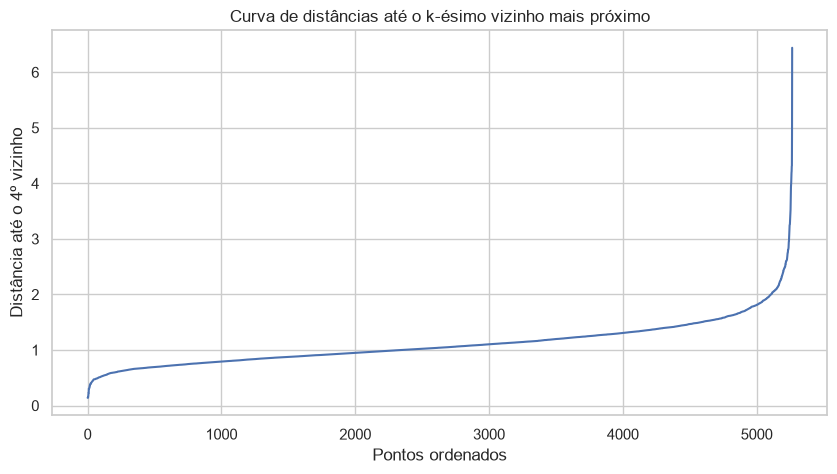

In [35]:
# Apoio para escolha de `eps` com gráfico de distâncias
min_samples = 4

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distancias_k = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(10, 5))
plt.plot(distancias_k)
plt.title('Curva de distâncias até o k-ésimo vizinho mais próximo')
plt.xlabel('Pontos ordenados')
plt.ylabel(f'Distância até o {min_samples}º vizinho')
plt.show()

In [36]:
eps_escolhido = 2
dbscan = DBSCAN(eps=eps_escolhido, min_samples=min_samples)
clusters = dbscan.fit_predict(X_scaled)

In [37]:
df['cluster'] = clusters
df.head()

,citric_acid,residual_sugar,chlorides,density,pH,sulphates,alcohol,quality,color,combined_acidity,combined_sulfur_dioxide,cluster
0,0.00,1.9,0.076,0.9978,3.51,0.56,9.4,5,0,0.194643,-82.339801,0
1,0.00,2.6,0.098,0.9968,3.20,0.68,9.8,5,0,0.599492,-47.003146,0
2,0.04,2.3,0.092,0.9970,3.26,0.65,9.8,5,0,0.596156,-61.956149,0
3,0.56,1.9,0.075,0.9980,3.16,0.58,9.8,6,0,3.981499,-55.656877,0
4,0.00,1.8,0.075,0.9978,3.51,0.56,9.4,5,0,0.193531,-76.040530,0


In [38]:
df['cluster'].value_counts().sort_index()

cluster
-1      89
 0    5162
 1       4
 2       4
 3       7
Name: count, dtype: int64

In [39]:
# Resumo de cada cluster

summary = df.groupby('cluster')[features + ['quality']].agg(
    ['mean', 'std', 'min', 'max']
)

summary

citric_acid                       residual_sugar                       \
               mean       std   min   max           mean       std  min   max   
cluster                                                                         
-1         0.440674  0.278632  0.00  1.66       6.330337  6.311919  1.1  31.6   
 0         0.314471  0.140676  0.00  1.00       5.027983  4.384509  0.6  23.5   
 1         0.365000  0.090000  0.24  0.44       2.275000  0.320156  1.8   2.5   
 2         0.207500  0.101119  0.12  0.30       1.825000  0.050000  1.8   1.9   
 3         0.360000  0.108474  0.20  0.49       2.557143  0.944911  1.5   4.5   

        chlorides            ... combined_sulfur_dioxide              \
             mean       std  ...                     min         max   
cluster                      ...                                       
-1       0.101820  0.080952  ...             -108.510027  376.755674   
 0       0.053887  0.025326  ...             -111.429443  216.792282   
 1       0.218750  0.006292  ...             -105.130171 -101.007396   
 2       0.164250  0.009912  ...             -105.360391  -73.707259   
 3       0.084000  0.011269  ...              -60.344608   32.124745   

          quality                                                
             mean       std min max      mean       std min max  
cluster                                                          
-1       5.449438  1.314355   3   9  5.449438  1.314355   3   9  
 0       5.805502  0.864455   3   9  5.805502  0.864455   3   9  
 1       6.000000  0.000000   6   6  6.000000  0.000000   6   6  
 2       5.750000  0.500000   5   6  5.750000  0.500000   5   6  
 3       5.142857  0.690066   4   6  5.142857  0.690066   4   6  

[5 rows x 44 columns]

In [40]:
# Redução dos dados para 2 dimensões usando PCA

df['cluster'] = clusters

from sklearn.decomposition import PCA

# Cria o modelo PCA para reduzir os dados para 2 componentes
pca = PCA(n_components=2)

# Aplica o PCA aos dados padronizados
X_pca = pca.fit_transform(X_scaled)

# Mostra a variância explicada pelos dois componentes
print("Variância explicada pelo PCA 1:", round(pca.explained_variance_ratio_[0], 4))
print("Variância explicada pelo PCA 2:", round(pca.explained_variance_ratio_[1], 4))
print("Variância explicada acumulada:", round(pca.explained_variance_ratio_.sum(), 4))

Variância explicada pelo PCA 1: 0.2618
Variância explicada pelo PCA 2: 0.2211
Variância explicada acumulada: 0.4829


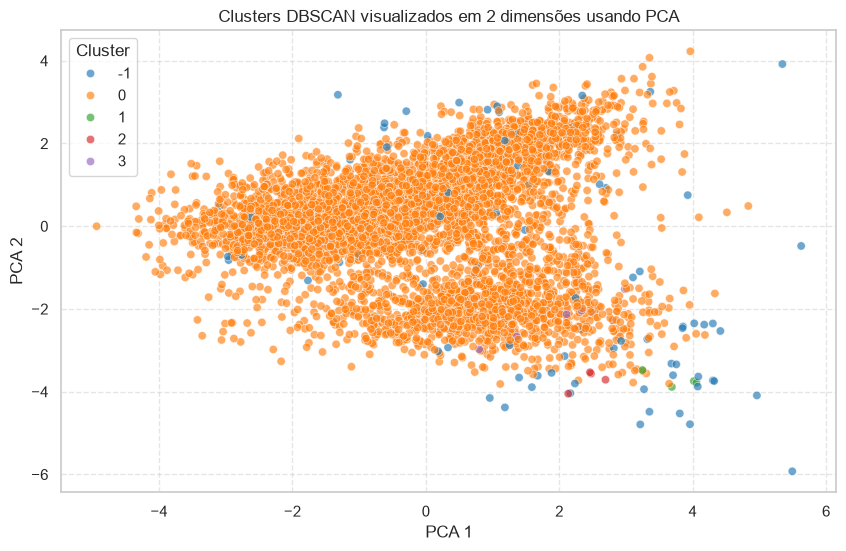

In [41]:
# Adicionando os componentes principais ao DataFrame

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# Gráfico PCA 1 x PCA 2, colorido pelos clusters do DBSCAN

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='PCA1',
    y='PCA2',
    hue='cluster',
    palette='tab10',
    alpha=0.65
)

plt.title('Clusters DBSCAN visualizados em 2 dimensões usando PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [42]:
# Obtém os pesos (loadings) das variáveis em PCA1 e PCA2

loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PCA1', 'PCA2'],
    index=features
)

print(loadings)

                             PCA1      PCA2
citric_acid              0.110418  0.166584
residual_sugar           0.252192  0.465720
chlorides                0.344219 -0.339831
density                  0.570892 -0.013042
pH                      -0.093460 -0.298574
sulphates                0.160031 -0.392282
alcohol                 -0.484590 -0.155916
combined_acidity         0.324287 -0.261161
combined_sulfur_dioxide  0.040419  0.550568
quality                 -0.322234 -0.032064


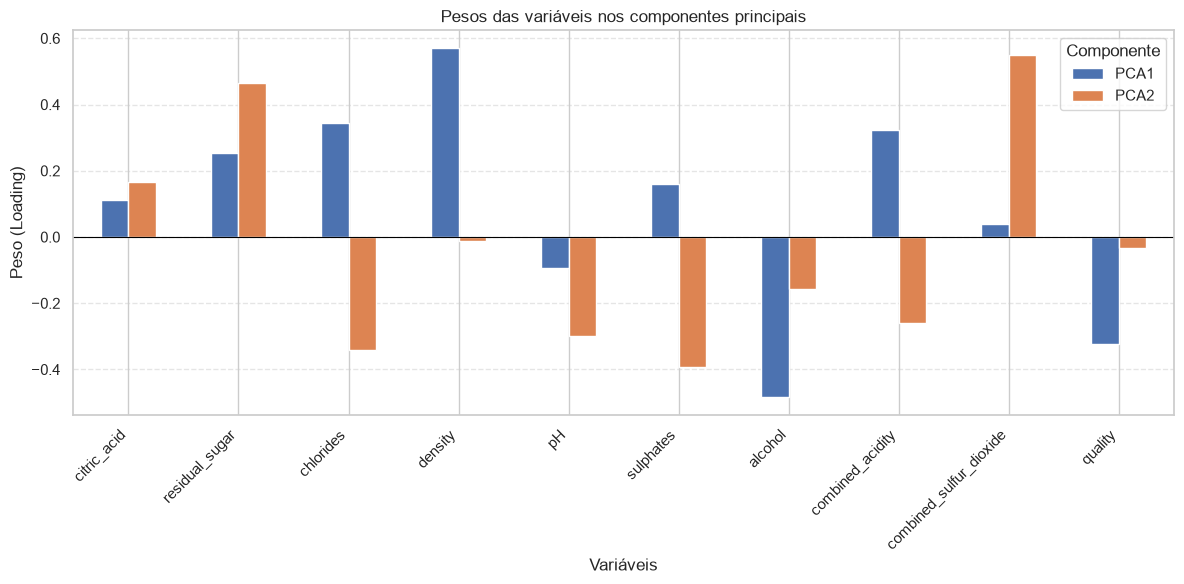

In [43]:
# Gráfico dos pesos das variáveis em PCA1 e PCA2

loadings.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Pesos das variáveis nos componentes principais')
plt.xlabel('Variáveis')
plt.ylabel('Peso (Loading)')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Componente')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Iniciando a busca pelos melhores parâmetros do DBSCAN...

=== RESULTADO DA ANÁLISE ===
Melhor Silhouette Score: 0.3015
Parâmetros ideais -> eps: 1.5 | min_samples: 25
Quantidade de clusters reais (excluindo ruídos): 2


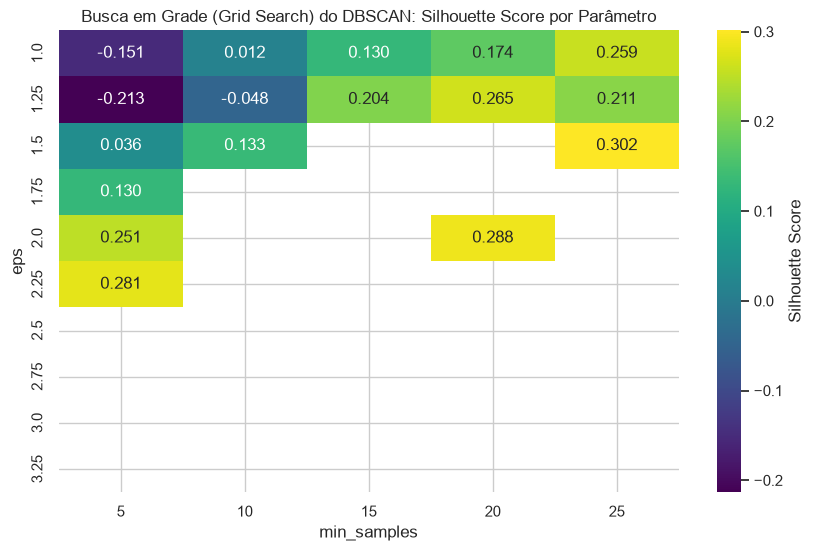

In [44]:
# Definindo os intervalos de busca (ajuste conforme a necessidade dos seus dados)
intervalo_eps = np.arange(1.0, 3.5, 0.25)  # Testa de 1.0 até 3.25 pulando de 0.25 em 0.25
intervalo_min_samples = [5, 10, 15, 20, 25]

# Dicionário para guardar os resultados para o gráfico de calor
resultados_grid = {}

melhor_score = -1
melhor_eps = None
melhor_min_samples = None
melhor_quantidade_clusters = None

print("Iniciando a busca pelos melhores parâmetros do DBSCAN...")

# Loop por todas as combinações de hiperparâmetros
for eps in intervalo_eps:
    for min_samples in intervalo_min_samples:
        # Configura e treina o DBSCAN
        db_teste = DBSCAN(eps=eps, min_samples=min_samples)
        labels_teste = db_teste.fit_predict(X_scaled)
        
        # Identifica as etiquetas únicas
        labels_unicos = set(labels_teste)
        
        # Remove o ruído (-1) da contagem de clusters para a validação da métrica
        if -1 in labels_unicos:
            labels_unicos.remove(-1)
            
        # O cálculo da silhueta exige que existam pelo menos 2 clusters definidos
        if len(labels_unicos) >= 2:
            # Filtra os dados removendo os pontos classificados como ruído (-1)
            mascara_sem_ruido = labels_teste != -1
            X_filtrado = X_scaled[mascara_sem_ruido]
            labels_filtrados = labels_teste[mascara_sem_ruido]
            
            # Calcula o score de silhueta apenas para as amostras válidas
            score = silhouette_score(X_filtrado, labels_filtrados)
            resultados_grid[(eps, min_samples)] = score
            
            # Atualiza os melhores parâmetros se encontrar um score maior
            if score > melhor_score:
                melhor_score = score
                melhor_eps = eps
                melhor_min_samples = min_samples
                melhor_quantidade_clusters = len(labels_unicos)
        else:
            # Caso a combinação resulte em apenas 1 cluster ou apenas ruído
            resultados_grid[(eps, min_samples)] = np.nan

# Exibe o veredito da busca no console
print("\n=== RESULTADO DA ANÁLISE ===")
if melhor_score > -1:
    print(f"Melhor Silhouette Score: {melhor_score:.4f}")
    print(f"Parâmetros ideais -> eps: {melhor_eps} | min_samples: {melhor_min_samples}")
    print(f"Quantidade de clusters reais (excluindo ruídos): {melhor_quantidade_clusters}")
else:
    print("Nenhuma combinação gerou pelo menos 2 clusters válidos para calcular o Silhouette Score.")

# --- CONSTRUÇÃO DO GRÁFICO DE CALOR (HEATMAP) ---
# Organiza os resultados em uma matriz (DataFrame) para o Seaborn
matriz_resultados = pd.DataFrame(index=intervalo_eps, columns=intervalo_min_samples, dtype=float)
for (eps, min_samples), score in resultados_grid.items():
    matriz_resultados.at[eps, min_samples] = score

# Plota o gráfico de calor
plt.figure(figsize=(10, 6))
sns.heatmap(matriz_resultados, annot=True, fmt=".3f", cmap="viridis", cbar_kws={'label': 'Silhouette Score'})
plt.title('Busca em Grade (Grid Search) do DBSCAN: Silhouette Score por Parâmetro')
plt.xlabel('min_samples')
plt.ylabel('eps')
plt.show()
